C:\Users\Mahima Varshini\anaconda3\Lib\site-packages\lightkurve\prf\__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


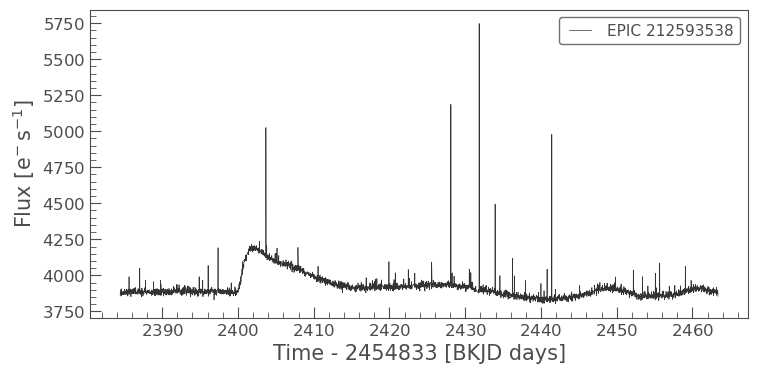

In [1]:
from lightkurve import search_targetpixelfile
tpf = search_targetpixelfile('EPIC 212593538', campaign=6).download()
lc = tpf.to_lightcurve(aperture_mask='all')
import matplotlib.pyplot as plt
lc.plot()
plt.show() #spike represents supernova

In [2]:
from lightkurve import search_targetpixelfile
planetA = search_targetpixelfile('Pi Mensae', mission='TESS', sector=1)
tpf = planetA.download(quality_bitmask='default')

C:\Users\Mahima Varshini\anaconda3\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [3]:
tpf.mission

'TESS'

In [4]:
tpf.targetid

261136679

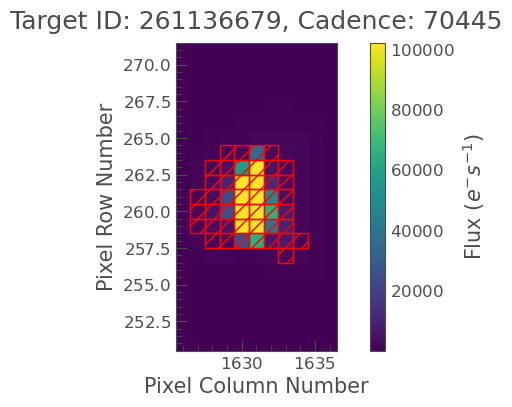

In [5]:
import matplotlib.pyplot as plt
tpf.plot(aperture_mask=tpf.pipeline_mask)
plt.show()

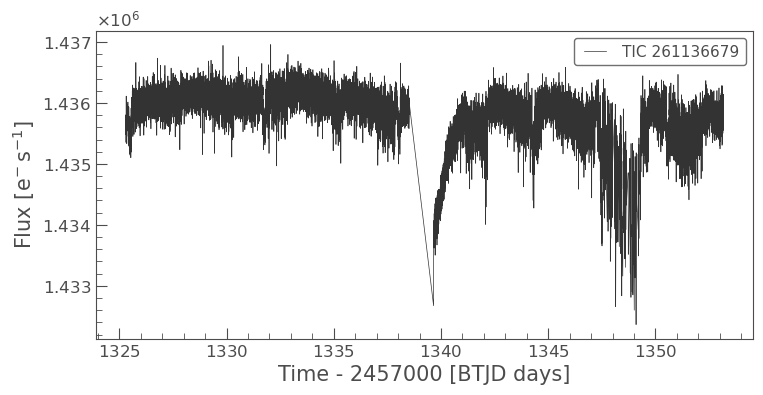

In [6]:
lc = tpf.to_lightcurve()
plt.close('all')
import matplotlib.pyplot as plt
lc.plot()
plt.show() #Requires data cleaning

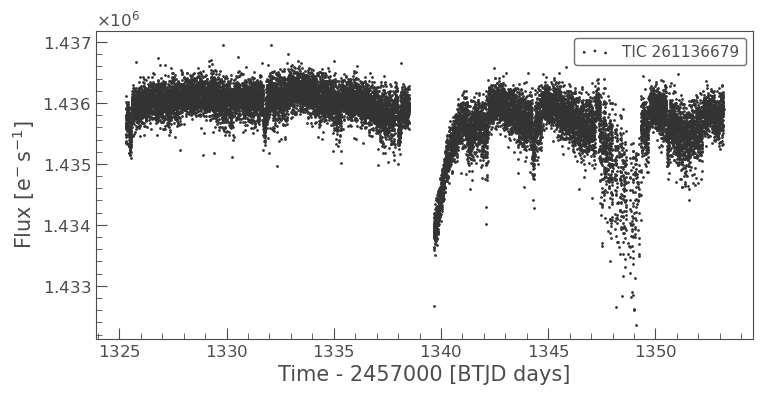

In [7]:
import matplotlib.pyplot as plt

lc.scatter()
plt.show()
plt.close('all')


In [8]:
#It is more convenient to analyse the plot if we only look at pixels that represent the star. Set the threshold accordingly

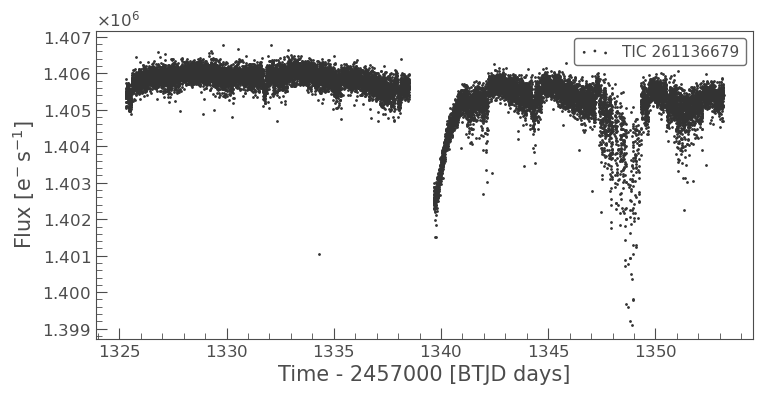

In [9]:
aperture_mask = tpf.create_threshold_mask(threshold=12)
lc = tpf.to_lightcurve(aperture_mask=aperture_mask)
import matplotlib.pyplot as plt

lc.scatter()
plt.show()
plt.close('all')

In [10]:
# Remove data points that consist of jitters from the telescope

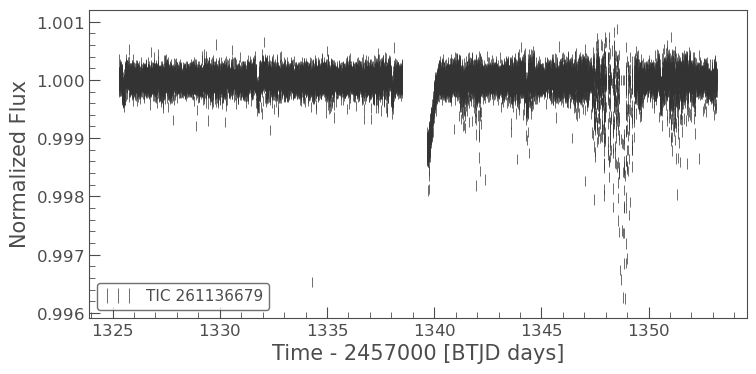

In [11]:
flat_lc = lc.flatten(window_length = 1001)
import matplotlib.pyplot as plt
plt.close('all')
flat_lc.errorbar()
plt.show()


In [12]:
#Small window: Follows the data closely, even small wiggles.
#Large window: Ignores small wiggles and only follows slow, broad changes.
#Error bar: It helps in judging how reliable each data point is, i.e., it is the uncertainity measurement plot

In [13]:
#Removing the area with unwanted data points

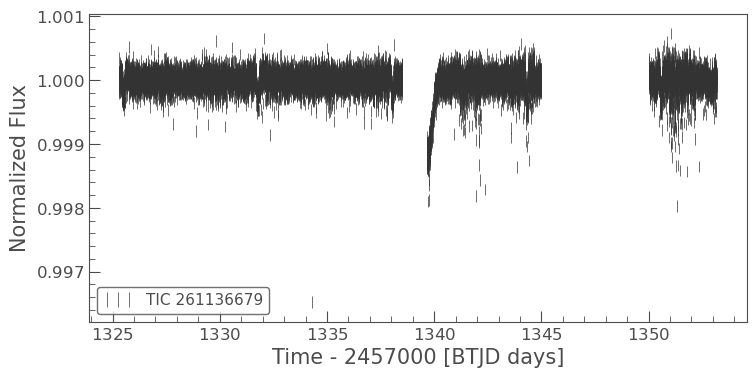

In [14]:
mask = (flat_lc.time.value < 1345) | (flat_lc.time.value > 1350)
import matplotlib.pyplot as plt
flat_lc = flat_lc[mask]
plt.close('all')
flat_lc.errorbar()
plt.show()

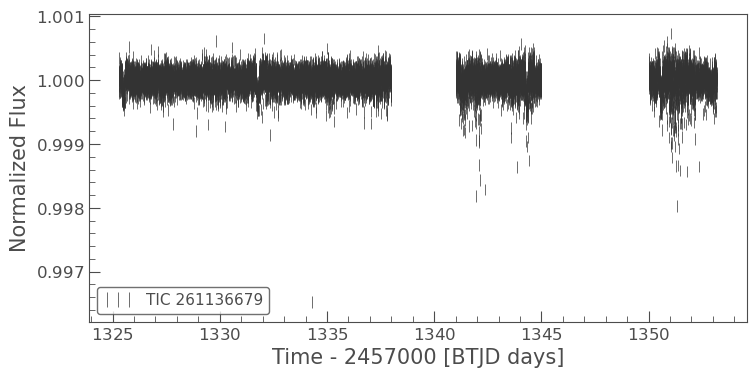

In [15]:
mask2 = (flat_lc.time.value < 1338) | (flat_lc.time.value > 1341)
import matplotlib.pyplot as plt
flat_lc = flat_lc[mask2]
plt.close('all')
flat_lc.errorbar()
plt.show()

In [16]:
# Remove outliers: lower the sigma, lesser the outliers 

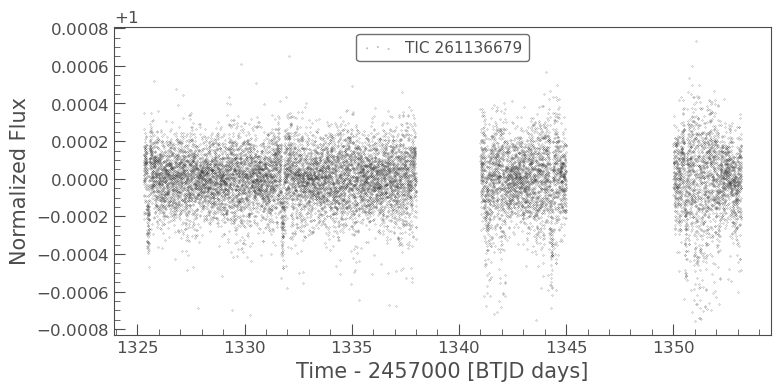

In [17]:
clipped_lc = flat_lc.remove_outliers(sigma=5)
import matplotlib.pyplot as plt
plt.close('all')
clipped_lc.scatter(s=0.1)
plt.show()

In [18]:
#For astronomy data, extreme outliers can come from: cosmic ray hits, detector problems, spacecraft pointing issues and bad measurements

In [19]:
# Find the strongest repeating pattern

In [20]:
import numpy as np
periodogram = clipped_lc.to_periodogram(method="bls", period=np.arange(1,10,0.001))


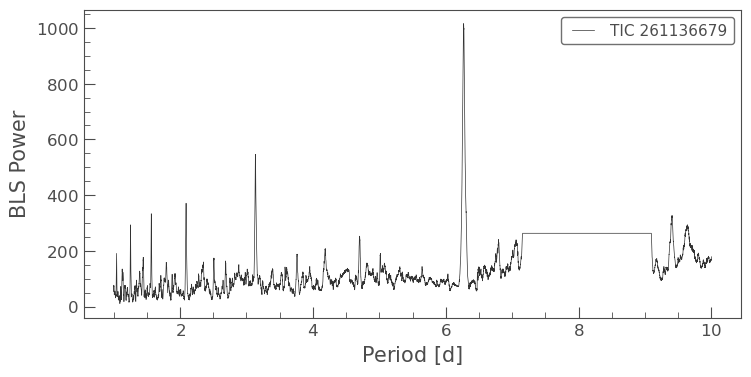

In [21]:
import matplotlib.pyplot as plt
plt.close('all')
periodogram.plot()
plt.show()

In [22]:
bestfitperiod = periodogram.period_at_max_power
bestfitperiod


<Quantity 6.269 d>

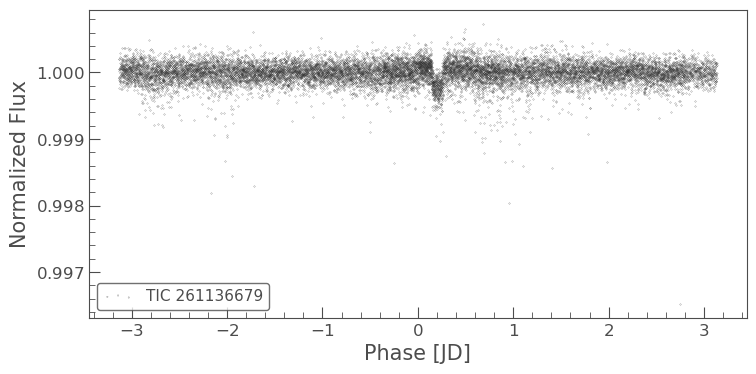

In [23]:
folded_lc = flat_lc.fold(period=6.269)
plt.close('all') 
folded_lc.scatter(s = 0.1);
import matplotlib.pyplot as plt
plt.show()

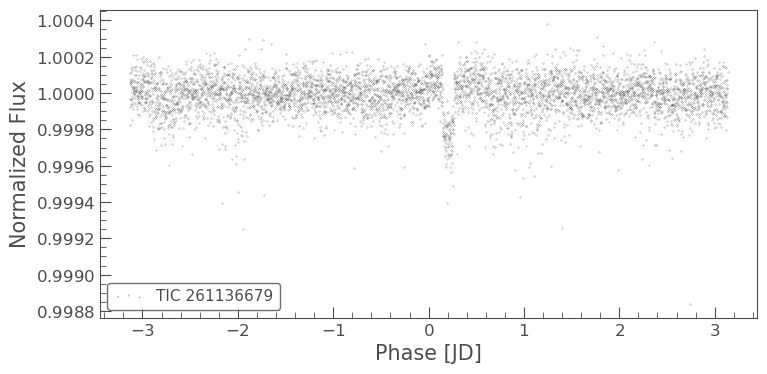

In [24]:
binned_lc = folded_lc.bin(bins=5000)
import matplotlib.pyplot as plt

binned_lc.scatter(s=0.1)
plt.show()
len(binned_lc); # should not be zero
len(folded_lc);

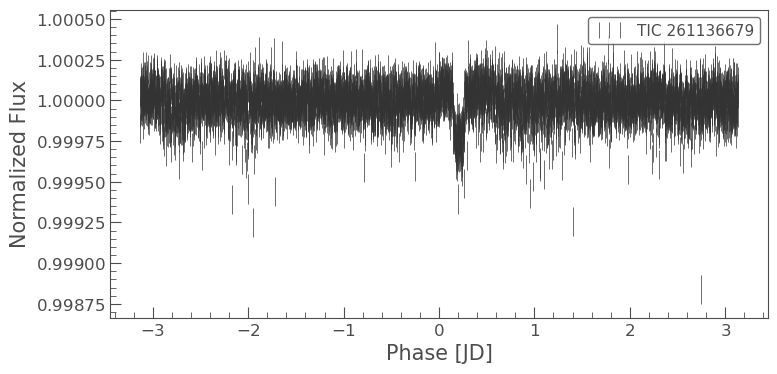

In [25]:
import matplotlib.pyplot as plt

binned_lc.errorbar()
plt.show()


In [26]:
# The depth of the dip in the error bar plot tells you how big the planet is. 
# Normal brightness: around 1.000 flux
# During transit: maybe 0.990 flux
# Measurement uncertainty: maybe ±0.001